In [1]:
# step 1 # load and explore the dataset
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import networkx as nx
import seaborn as sns
import torch
import torch.nn.functional as F
import random


In [2]:
def load_triples(path):
    triples = []
    with open(path, "r") as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) == 3:
                triples.append(tuple(parts))
    return triples

train_triples = load_triples("../data/train.txt")
test_triples = load_triples("../data/test.txt")


In [3]:
entities = sorted(
    {h for h, r, t in train_triples} |
    {t for h, r, t in train_triples}
)

relations = sorted({r for h, r, t in train_triples})

ent2id = {e: i for i, e in enumerate(entities)}
rel2id = {r: i for i, r in enumerate(relations)}


In [4]:
def triples_to_tensor(triples, ent2id, rel2id):
    return torch.tensor(
        [[ent2id[h], rel2id[r], ent2id[t]] for h, r, t in triples],
        dtype=torch.long
    )

train_tensor = triples_to_tensor(train_triples, ent2id, rel2id)
test_tensor = triples_to_tensor(test_triples, ent2id, rel2id)

In [5]:
num_entities = len(ent2id)
num_relations = len(rel2id)
embedding_dim = 200

ent_re = torch.randn(num_entities, embedding_dim, requires_grad=True)
ent_im = torch.randn(num_entities, embedding_dim, requires_grad=True)

rel_re = torch.randn(num_relations, embedding_dim, requires_grad=True)
rel_im = torch.randn(num_relations, embedding_dim, requires_grad=True)


In [6]:
def complex_score(h, r, t, ent_re, ent_im, rel_re, rel_im):
    h_re, h_im = ent_re[h], ent_im[h]
    r_re, r_im = rel_re[r], rel_im[r]
    t_re, t_im = ent_re[t], ent_im[t]

    score = (
        h_re * r_re * t_re +
        h_im * r_re * t_im +
        h_re * r_im * t_im -
        h_im * r_im * t_re
    ).sum(dim=1)

    return score



In [7]:
def negative_sampling(triples, num_entities):
    neg = triples.clone()
    for i in range(len(neg)):
        if random.random() < 0.5:
            neg[i, 0] = random.randint(0, num_entities - 1)
        else:
            neg[i, 2] = random.randint(0, num_entities - 1)
    return neg


In [8]:
optimizer = torch.optim.Adam(
    [ent_re, ent_im, rel_re, rel_im],
    lr=0.002
)

epochs = 350
batch_size = 256
losses = []

for epoch in range(epochs):
    perm = torch.randperm(train_tensor.size(0))
    epoch_loss = 0.0

    for i in range(0, train_tensor.size(0), batch_size):
        batch = train_tensor[perm[i:i + batch_size]]

        neg_batch = negative_sampling(batch, num_entities)

        pos_score = complex_score(batch[:, 0],batch[:, 1],batch[:, 2],ent_re, ent_im, rel_re, rel_im)

        neg_score = complex_score(neg_batch[:, 0],neg_batch[:, 1],neg_batch[:, 2],ent_re, ent_im, rel_re, rel_im)

        loss = (
            F.binary_cross_entropy_with_logits(
                pos_score, torch.ones_like(pos_score)
            ) +
            F.binary_cross_entropy_with_logits(
                neg_score, torch.zeros_like(neg_score)
            )
        )

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    losses.append(epoch_loss)
    print(f"Epoch {epoch+1}/{epochs} | Loss: {epoch_loss:.4f}")


Epoch 1/350 | Loss: 1200.7378
Epoch 2/350 | Loss: 1081.3693
Epoch 3/350 | Loss: 982.7928
Epoch 4/350 | Loss: 909.0604
Epoch 5/350 | Loss: 840.0812
Epoch 6/350 | Loss: 779.7501
Epoch 7/350 | Loss: 728.8878
Epoch 8/350 | Loss: 686.1456
Epoch 9/350 | Loss: 638.9271
Epoch 10/350 | Loss: 612.7663
Epoch 11/350 | Loss: 578.9810
Epoch 12/350 | Loss: 563.4400
Epoch 13/350 | Loss: 545.0797
Epoch 14/350 | Loss: 525.0569
Epoch 15/350 | Loss: 502.6869
Epoch 16/350 | Loss: 501.5288
Epoch 17/350 | Loss: 493.6422
Epoch 18/350 | Loss: 476.5140
Epoch 19/350 | Loss: 459.1527
Epoch 20/350 | Loss: 460.6665
Epoch 21/350 | Loss: 459.4186
Epoch 22/350 | Loss: 452.6033
Epoch 23/350 | Loss: 437.5072
Epoch 24/350 | Loss: 428.1392
Epoch 25/350 | Loss: 425.2127
Epoch 26/350 | Loss: 412.6349
Epoch 27/350 | Loss: 410.9508
Epoch 28/350 | Loss: 409.7894
Epoch 29/350 | Loss: 398.6416
Epoch 30/350 | Loss: 390.7375
Epoch 31/350 | Loss: 394.2718
Epoch 32/350 | Loss: 388.3664
Epoch 33/350 | Loss: 377.8343
Epoch 34/350 | Lo

In [9]:
def evaluate_link_prediction(
    test_triples,
    ent_re, ent_im,
    rel_re, rel_im,
    num_entities
):
    ranks = []

    with torch.no_grad():
        for h, r, t in test_triples:
            h = h.unsqueeze(0)
            r = r.unsqueeze(0)

            candidates = torch.arange(num_entities)

            h_expand = h.repeat(num_entities)
            r_expand = r.repeat(num_entities)

            scores = complex_score(
                h_expand, r_expand, candidates,
                ent_re, ent_im, rel_re, rel_im
            )

            # Higher score = more likely
            sorted_indices = torch.argsort(scores, descending=True)

            rank = (sorted_indices == t).nonzero(as_tuple=True)[0].item() + 1
            ranks.append(rank)

    ranks = torch.tensor(ranks, dtype=torch.float)

    mrr = torch.mean(1.0 / ranks).item()
    hits1 = torch.mean((ranks <= 1).float()).item()
    hits10 = torch.mean((ranks <= 10).float()).item()

    return mrr, hits1, hits10


In [10]:
mrr, hits1, hits10 = evaluate_link_prediction(
    test_tensor,
    ent_re, ent_im,
    rel_re, rel_im,
    num_entities=len(ent2id)
)

print(f"MRR    : {mrr:.4f}")
print(f"Hits@1 : {hits1:.4f}")
print(f"Hits@10: {hits10:.4f}")


MRR    : 0.3711
Hits@1 : 0.0186
Hits@10: 0.9322


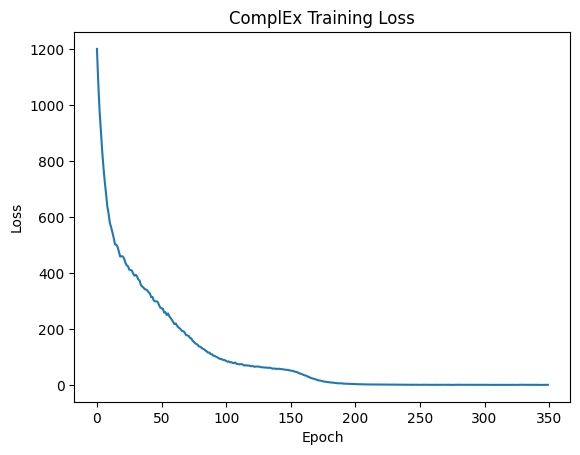

In [11]:
plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("ComplEx Training Loss")
plt.show()
